# **Part 2: Finite Element Mass and Stiffness Matrix Assembly**

## **Objectives**

Previously we constructed and verified a two-dimensional triangular mesh. Now we consider this mesh to construct the finite element matrices required for solving the time-dependent diffusion equation.

The objectives of Part 2 are to:

1. Introduce linear basis functions on a triangular element;
2. Calculate the gradients of the basis functions;
3. Derive the local element mass matrix;
4. Derive the local diffusion stiffness matrix;
5. Assemble the local matrices into global matrices; and
6. Verify the dimensions, symmetry and numerical properties of the assembled matrices.
## **Governing Diffusion Equation**

The initial mathematical model is the two-dimensional diffusion equation:

$$
\frac{\partial c}{\partial t}
=
D\nabla^2c
\qquad \text{in } \Omega,
$$

where:

- $c(x,y,t)$ is the concentration of the diffusing species;
- $D$ is the diffusion coefficient;
- $t$ represents time;
- $\nabla^2c$ is the Laplacian of the concentration; and
- $\Omega$ is the two-dimensional computational domain.

The Laplacian in Cartesian coordinates is

$$
\nabla^2c
=
\frac{\partial^2c}{\partial x^2}
+
\frac{\partial^2c}{\partial y^2}.
$$

The outer boundary is initially assumed to be insulated:

$$
-D\nabla c\cdot\mathbf{n}=0
\qquad \text{on } \partial\Omega,
$$

where $\mathbf{n}$ is the outward unit normal vector.

This boundary condition means that no concentration flux passes through the outer boundary.


## **Weak Formulation**

Multiplying the diffusion equation by a test function $v$ and applying integration by parts gives

$$
\int_\Omega
v\frac{\partial c}{\partial t}\,d\Omega
+
D\int_\Omega
\nabla v\cdot\nabla c\,d\Omega
=0.
$$

After finite element discretization, the system becomes

$$
M\frac{d\mathbf{c}}{dt}+K\mathbf{c}=0,
$$

where $M$ is the global mass matrix and $K$ is the global stiffness matrix.

---

## **Linear Finite Element Approximation**

Inside each triangular element, the concentration is approximated by

$$
c_h(x,y,t)
=
\sum_{i=1}^{3}c_i(t)N_i(x,y),
$$

where $N_i(x,y)$ are the linear triangular basis functions and $c_i(t)$ are the nodal concentration values.

The basis functions satisfy

$$
N_i(x_j,y_j)
=
\begin{cases}
1, & i=j,\\
0, & i\neq j,
\end{cases}
$$

and

$$
N_1+N_2+N_3=1.
$$

---

## **Area of a Triangular Element**

For a triangular element with vertices

$$
(x_1,y_1),\qquad
(x_2,y_2),\qquad
(x_3,y_3),
$$

the signed area is

$$
A_e
=
\frac{1}{2}
\left[
(x_2-x_1)(y_3-y_1)
-
(x_3-x_1)(y_2-y_1)
\right].
$$

A positive area indicates counter-clockwise node ordering:

$$
A_e>0.
$$

---

## **Basis-Function Gradients**

The coefficients used to calculate the basis-function gradients are

$$
b_1=y_2-y_3,
\qquad
b_2=y_3-y_1,
\qquad
b_3=y_1-y_2,
$$

and

$$
c_1=x_3-x_2,
\qquad
c_2=x_1-x_3,
\qquad
c_3=x_2-x_1.
$$

The gradient of each basis function is

$$
\nabla N_i
=
\frac{1}{2A_e}
\begin{bmatrix}
b_i\\
c_i
\end{bmatrix}.
$$

The gradient matrix used in the code is

$$
B_e
=
\frac{1}{2A_e}
\begin{bmatrix}
b_1 & c_1\\
b_2 & c_2\\
b_3 & c_3
\end{bmatrix}.
$$

---

## **Local Mass Matrix**

The entries of the local mass matrix are

$$
M_{ij}^{(e)}
=
\int_{\Omega_e}N_iN_j\,d\Omega.
$$

For a three-node linear triangular element,

$$
M^{(e)}
=
\frac{A_e}{12}
\begin{bmatrix}
2&1&1\\
1&2&1\\
1&1&2
\end{bmatrix}.
$$

The local mass matrix is symmetric:

$$
M^{(e)}=\left(M^{(e)}\right)^T.
$$

---

## **Local Stiffness Matrix**

The entries of the local diffusion stiffness matrix are

$$
K_{ij}^{(e)}
=
D\int_{\Omega_e}
\nabla N_i\cdot\nabla N_j\,d\Omega.
$$

Using the basis-function gradients, the local stiffness matrix is

$$
K^{(e)}
=
D A_e B_eB_e^T.
$$

Equivalently, each entry is

$$
K_{ij}^{(e)}
=
\frac{D}{4A_e}
\left(
b_ib_j+c_ic_j
\right).
$$

The local stiffness matrix is symmetric:

$$
K^{(e)}=\left(K^{(e)}\right)^T.
$$

---

## **Global Matrix Assembly**

If local nodes $i$ and $j$ correspond to global nodes $I$ and $J$, the local matrix entries are added to the global matrices using

$$
M_{IJ}
\leftarrow
M_{IJ}+M_{ij}^{(e)}
$$

and

$$
K_{IJ}
\leftarrow
K_{IJ}+K_{ij}^{(e)}.
$$

For 169 global nodes, both assembled matrices have dimensions

$$
M,K\in\mathbb{R}^{169\times169}.
$$

---

## **Matrix Verification**

The global matrices should be symmetric:

$$
M=M^T
$$

and

$$
K=K^T.
$$

Their diagonal entries should be positive:

$$
M_{ii}>0,
\qquad
K_{ii}>0.
$$

The sum of all mass-matrix entries should equal the area of the domain:

$$
\sum_{i,j}M_{ij}
=
L_xL_y.
$$

For the unit-square domain,

$$
\sum_{i,j}M_{ij}=1.
$$

For the constant vector $\mathbf{1}$, the stiffness matrix should satisfy

$$
K\mathbf{1}=\mathbf{0}.
$$

Therefore, every stiffness-matrix row should sum to approximately zero:

$$
\sum_jK_{ij}\approx0.
$$

A small value such as $10^{-15}$ is considered numerical zero and is caused by floating-point rounding.

Mesh successfully reconstructed.
Number of nodes: 169
Number of elements: 288
Total mesh area: 1.0
Number of nodes: 169
Number of elements: 288
Diffusion coefficient: 1.0
Initial mass matrix shape: (169, 169)
Initial stiffness matrix shape: (169, 169)
Global mass and stiffness matrices assembled.
First element global nodes:
[ 0  1 14]

First element coordinates:
[[0.         0.        ]
 [0.08333333 0.        ]
 [0.08333333 0.08333333]]

First element area:
0.003472222222222222

Basis-function gradients:
[[-12.   0.]
 [ 12. -12.]
 [  0.  12.]]

Local mass matrix:
[[0.0005787  0.00028935 0.00028935]
 [0.00028935 0.0005787  0.00028935]
 [0.00028935 0.00028935 0.0005787 ]]

Local stiffness matrix:
[[ 0.5 -0.5  0. ]
 [-0.5  1.  -0.5]
 [ 0.  -0.5  0.5]]

Global mass matrix shape: (169, 169)

Global stiffness matrix shape: (169, 169)

Number of nonzero mass-matrix entries: 1081

Number of nonzero stiffness-matrix entries: 793
Mass-matrix symmetry error: 0.0
Stiffness-matrix symmetry error: 0

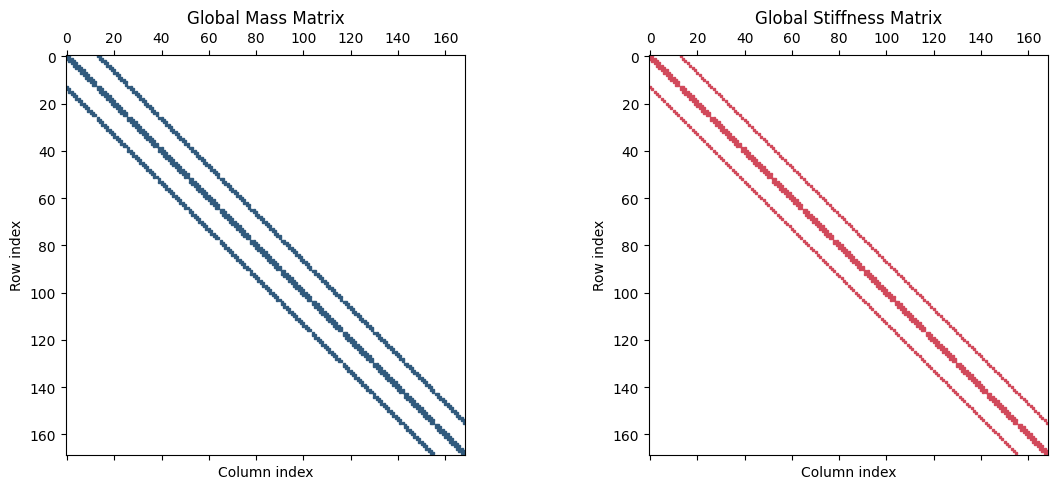

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0, Lx, Nx + 1)
y = np.linspace(0.0, Ly, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1, n2, n4])
        elements.append([n1, n4, n3])
elements = np.asarray(elements, dtype=int)
# Calculate the signed areas
def calculate_signed_areas(node_coordinates,connectivity):
    p1 = node_coordinates[connectivity[:, 0]]
    p2 = node_coordinates[connectivity[:, 1]]
    p3 = node_coordinates[connectivity[:, 2]]
    areas = 0.5 * ((p2[:, 0] - p1[:, 0])* (p3[:, 1] - p1[:, 1])-(p3[:, 0] - p1[:, 0])* (p2[:, 1] - p1[:, 1]))
    return areas
number_of_nodes = len(nodes)
number_of_elements = len(elements)
D = 1.0
element_areas = calculate_signed_areas(nodes,elements)
print("Mesh successfully reconstructed.")
print("Number of nodes:", len(nodes))
print("Number of elements:", len(elements))
print("Total mesh area:", element_areas.sum())
print("Number of nodes:", number_of_nodes)
print("Number of elements:", number_of_elements)
print("Diffusion coefficient:", D)
# Initialize the global mass and stiffness matrices
global_mass = np.zeros((number_of_nodes, number_of_nodes))
global_stiffness = np.zeros((number_of_nodes, number_of_nodes))
print("Initial mass matrix shape:", global_mass.shape)
print("Initial stiffness matrix shape:",global_stiffness.shape)
# Variables for storing the results of the first element
first_element_nodes = None
first_element_coordinates = None
first_element_area = None
first_element_gradients = None
first_element_mass = None
first_element_stiffness = None

for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]

    area = element_areas[element_index]
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found." )
    b_coefficients = np.array([
        y2 - y3,
        y3 - y1,
        y1 - y2])
    c_coefficients = np.array([
        x3 - x2,
        x1 - x3,
        x2 - x1])
    basis_gradients = np.column_stack((b_coefficients,c_coefficients)) / (2.0 * area)
    local_mass = (area / 12.0) * np.array([
        [2.0, 1.0, 1.0],
        [1.0, 2.0, 1.0],
        [1.0, 1.0, 2.0]])
    local_stiffness = (D* area* (basis_gradients @ basis_gradients.T))
    if element_index == 0:
        first_element_nodes = element.copy()
        first_element_coordinates = coordinates.copy()
        first_element_area = area
        first_element_gradients = (basis_gradients.copy())
        first_element_mass = local_mass.copy()
        first_element_stiffness = (local_stiffness.copy())
    # Assemble the local matrices into the global matrices
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i, global_j] += (local_mass[local_i, local_j])
            global_stiffness[global_i, global_j] += (local_stiffness[local_i, local_j])
print("Global mass and stiffness matrices assembled.")
np.set_printoptions(precision=8,
    suppress=True)
print("First element global nodes:")
print(first_element_nodes)
print("\nFirst element coordinates:")
print(first_element_coordinates)
print("\nFirst element area:")
print(first_element_area)
print("\nBasis-function gradients:")
print(first_element_gradients)
print("\nLocal mass matrix:")
print(first_element_mass)
print("\nLocal stiffness matrix:")
print(first_element_stiffness)
print("\nGlobal mass matrix shape:",global_mass.shape)
print("\nGlobal stiffness matrix shape:",global_stiffness.shape)
print("\nNumber of nonzero mass-matrix entries:",np.count_nonzero(global_mass))
print("\nNumber of nonzero stiffness-matrix entries:",np.count_nonzero(global_stiffness))
# Expected matrix dimensions
expected_matrix_shape = (
    number_of_nodes,
    number_of_nodes)

# Calculate symmetry errors
mass_symmetry_error = np.max(np.abs(global_mass - global_mass.T))
stiffness_symmetry_error = np.max(np.abs(global_stiffness-global_stiffness.T))
# Sum of all mass-matrix entries
mass_matrix_sum = np.sum(global_mass)
# Sum of every stiffness-matrix row
stiffness_row_sums = np.sum(global_stiffness,axis=1)
maximum_stiffness_row_sum = np.max(np.abs(stiffness_row_sums))
# Check the constant nullspace
constant_vector = np.ones(number_of_nodes)
constant_nullspace_error = np.max(np.abs(global_stiffness@ constant_vector))
# Perform verification checks
assert global_mass.shape == expected_matrix_shape, "The mass matrix has incorrect dimensions."
assert global_stiffness.shape == expected_matrix_shape, "The stiffness matrix has incorrect dimensions."
assert mass_symmetry_error < 1.0e-12, "The mass matrix is not symmetric."
assert stiffness_symmetry_error < 1.0e-12, "The stiffness matrix is not symmetric."
assert np.all(np.diag(global_mass) > 0.0), "The mass matrix has a non-positive diagonal entry."
assert np.all(np.diag(global_stiffness) > 0.0), "The stiffness matrix has a non-positive diagonal entry."
assert np.isclose(mass_matrix_sum, Lx * Ly), "The mass-matrix sum does not match the domain area."
assert maximum_stiffness_row_sum < 1.0e-12, "The stiffness-matrix rows do not sum to zero."
print("Mass-matrix symmetry error:",mass_symmetry_error)
print("Stiffness-matrix symmetry error:",stiffness_symmetry_error)
print("Sum of mass-matrix entries:",mass_matrix_sum)
print("Maximum absolute stiffness row sum:",maximum_stiffness_row_sum)
print("Constant-nullspace error:",constant_nullspace_error)
print("\nAll global matrix checks passed successfully.")

plt.figure(figsize=(12, 5))
# Global mass matrix
plt.subplot(1, 2, 1)
plt.spy( global_mass, markersize=1.5, color="#315A7D")
plt.title("Global Mass Matrix")
plt.xlabel("Column index")
plt.ylabel("Row index")
# Global stiffness matrix
plt.subplot(1, 2, 2)
plt.spy( global_stiffness, markersize=1.5, color="#D1495B")
plt.title("Global Stiffness Matrix")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.tight_layout()
plt.savefig("global_matrix_structure.png",dpi=300,bbox_inches="tight")
plt.show()


So, the local mass and diffusion stiffness matrices were calculated for every triangular element and assembled into global matrices using the element-connectivity.

For the **169-node mesh**, both global matrices had dimensions $169\times169$. The matrices were symmetric and had positive diagonal entries. The sum of all mass-matrix entries was approximately equal to the domain area:

$$
\sum_{i,j}M_{ij}\approx1.
$$

The stiffness-matrix row sums and constant-nullspace error were approximately zero, confirming the expected property

$$
K\mathbf{1}\approx\mathbf{0}.
$$

All verification checks passed successfully. The assembled matrices provide the semi-discrete finite element system

$$
M\frac{d\mathbf{c}}{dt}+K\mathbf{c}=0.
$$

In Part 3, the implicit Euler method will be applied to this system to calculate the time-dependent concentration distribution.
